## **The Ideal Case**
In this scenario, we process clean and undistorted plate images where all characters are clearly visible.

#### **Task 1:**  
Writing a function that takes a license plate image as input and split the image into its individual characters (both digits and letters) and plots each segmented character.

In [89]:
from PIL import Image
from PIL import ImageOps
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [63]:
# The function splits the image vertically from given points.
# slicing_points (list of [int, int, int, int]): List of [start_x, end_x, start_y, end_y] pairs for cropping. start_y and end_y are the same for all.
# save_slices (bool) is a Boolean which is True if we want to save the resulting slices images.
# print_slices (bool): Whether to display each slice inline
# image_number is used in the number of slice file saved.

# Finally, it returns a list of PIL.Image objects representing each vertical slice.
def character_splitter (img, image_name, slicing_points, loading_needed=True, output_directory = 'ideal_slices', save_slices = False, print_slices = False):
    if(loading_needed):
        img = Image.open(img)

    width, height = img.size

    sliced_images = []
    for i, (start_x, end_x, start_y, end_y) in enumerate(slicing_points):
        # Clamp coordinates to image bounds
        left = max(0, min(start_x, width))
        right = max(0, min(end_x, width))

        up = max(0, min(start_y, height))
        down = max(0, min(end_y, height))
        
        # Ensure left < right
        if left >= right:
            continue  # Skip invalid regions
        # The same for the vertical bounds
        if up >= down:
            continue
        
        crop_box = (left, up, right, down)
        sliced_img = img.crop(crop_box)
        sliced_images.append(sliced_img)

        if save_slices:
            if not os.path.exists(output_directory):
                os.makedirs(output_directory)
            filename = f"{output_directory}/{image_name}_slice_{i}.png"
            sliced_img.save(filename)

        if print_slices:
            print(f"Slice {i} ({left}px to {right}px):")
            display(sliced_img)
            
    return sliced_images

In [64]:
# # testing the size of the sample images
# img = Image.open('ideal1.jpg')
# print(img.size)
# # (758, 171)

# Now calling the function to cut all ideal samples (the pixel numbers for the slices are determined by trial and error):
character_splitter('ideal1.jpg', 'ideal1', [[132, 205, 25, 150], [205, 280, 25, 150], [310, 390, 25, 150], [420, 490, 25, 150], [488, 567, 25, 150], [563, 642, 25, 150], [640, 710, 25, 150]], save_slices=True)
character_splitter('ideal2.jpg', 'ideal2', [[130, 200, 25, 150], [200, 277, 25, 150], [300, 400, 25, 150], [420, 502, 25, 150], [496, 577, 25, 150], [572, 647, 25, 150], [643, 717, 25, 150]], save_slices=True)
character_splitter('ideal3.jpg', 'ideal3', [[132, 205, 25, 150], [203, 278, 25, 150], [310, 393, 25, 150], [420, 487, 25, 150], [483, 559, 25, 150], [553, 630, 25, 150], [625, 705, 25, 150]], save_slices=True)
character_splitter('ideal4.jpg', 'ideal4', [[125, 200, 25, 150], [197, 274, 25, 150], [300, 400, 25, 150], [420, 505, 25, 150], [499, 577, 25, 150], [572, 647, 25, 150], [643, 719, 25, 150]], save_slices=True)


[<PIL.Image.Image image mode=RGB size=75x125>,
 <PIL.Image.Image image mode=RGB size=77x125>,
 <PIL.Image.Image image mode=RGB size=100x125>,
 <PIL.Image.Image image mode=RGB size=85x125>,
 <PIL.Image.Image image mode=RGB size=78x125>,
 <PIL.Image.Image image mode=RGB size=75x125>,
 <PIL.Image.Image image mode=RGB size=76x125>]

#### **Task 2**: 
Now, using the provided technique, recognizing each character and printing the final license plate plus the correlation values as output:

In [65]:
# PART 0: A function that pads an image until it is the same size as another. The reason why we need this is explained in the next block.

def pad_images_to_match_size(img1, img2, fill=255):
    # Pads the smaller image (in width and height) so that both images have the same dimensions.
    # Padding is done symmetrically (equal on both sides).
    # fill is the padding color

    # converting both to grayscale if needed
    img1 = img1.convert('L')
    img2 = img2.convert('L')

    w1, h1 = img1.size
    w2, h2 = img2.size

    target_width = max(w1, w2)
    target_height = max(h1, h2)

    def pad_to_size(img, target_w, target_h):
        w, h = img.size
        pad_w = (target_w - w)
        pad_h = (target_h - h)
        padding = (
            pad_w // 2,           # left
            pad_h // 2,           # top
            pad_w - pad_w // 2,   # right
            pad_h - pad_h // 2    # bottom
        )
        return ImageOps.expand(img, padding, fill=fill)

    return pad_to_size(img1, target_width, target_height), pad_to_size(img2, target_width, target_height)


In [ ]:
# PART 1: Writing a function that computes the 1D correlation between
# a digit slice and a digit template and outputs the correlation value.

# For adapting the 1D algorithm of correlation to 2D images, what we do here
# is treating the images row-wise or column-wise. Each row / column can be
# viewed as a 1D array, ready for the 1D algorithm to be implemented. 

def image_correlation_1D(slice_img, template_img):
    # Convert both to grayscale
    slice_gray = slice_img.convert('L')
    template_gray = template_img.convert('L')

    # # Resize template to match height of slice (preserving aspect ratio roughly)
    # template_gray = template_gray.resize(slice_gray.size)

    # After writing the line above, we tested and realized that the algorithm does not have enough precision. For example it mistakes 5 for 6, B for 0 and D for 0.
    # One reason is that when resizing, the image ratio changes. So, we decided to pad the  smaller image with white instead.
    padded_slice, padded_template = pad_images_to_match_size(slice_gray, template_gray)

    # Flatten to 1D float arrays
    f = np.asarray(padded_slice,   dtype=np.float32).ravel()
    t = np.asarray(padded_template, dtype=np.float32).ravel()

    # Now normalizing the arrays. Normalization means subtracting the data from its mean (centering around 0) 
    # and dividing by the standard deviation (scaling to unit variance).
    # 
    # This may not be necessary in this ideal case we are investigating here, but it is logically and generally better to be present, plus it is necessary for 
    # the part investigate down sampled images. Genral reasons are:
    #   1. Makes Correlation Independent of Brightness/Contrast:
    #      Without normalization, two images of the same digit (e.g. "5") with different brightness or contrast will have very different pixel values,
    #      even though visually they're the same.
    #   2. Ensures fair comparison in cases where the digits have noise and shadows, or the image is brighter / darker overall
    #   3. Prevents One Array from Dominating:
    #      In dot-product-based correlation, unnormalized vectors let high-magnitude signals dominate the result — even if their shape doesn't match.
    #      By normalizing, we even the odds!

    # first, zero-centering:
    f_mean, t_mean = f.mean(), t.mean()
    f_centered = f - f_mean
    t_centered = t - t_mean

    # Compute denominator (avoiding zero‐division)
    f_norm = np.linalg.norm(f_centered)
    t_norm = np.linalg.norm(t_centered)
    eps = 1e-8
    if f_norm < eps or t_norm < eps:
        return -1.0

    # Correlation Coefficient
    correlation_coeff = (f_centered @ t_centered) / (f_norm * t_norm)
    return correlation_coeff


In [67]:
# PART 2: Loading the template characters into a dictionary
def char_load():
    templates = {}
    for digit in range(10):
        path = f"numbers/{digit}.jpg"
        templates[str(digit)] = Image.open(path)

    templates[10] = Image.open("letters/A.jpg")
    templates[11] = Image.open("letters/B.jpg")
    templates[12] = Image.open("letters/C.jpg")
    templates[13] = Image.open("letters/D.jpg")

    return templates

In [68]:
# PART 3: Now putting them all together in a function to form the whole algorithm
def LPR(image_number, slices, templates, downsampled=False, factor=None):
    license_number = ""
    best_correlation_scores = []
    # slices is a list
    for i, slc_img in enumerate(slices):
        best_digit = None
        best_score = -np.inf
        
        # templates is a dictionary
        for digit, tmpl_img in templates.items():
            score = image_correlation_1D(slc_img, tmpl_img)

            if(downsampled == False): # since in the downsampling part the number of times we call this function is a lot and the output n=box gets messy
                print(f"Image{image_number}, Digit{i}, Template {digit} → correlation: {score:.3f}")
            
            if score >  best_score:
                best_score = score
                best_digit = digit

        if(best_digit == 10):
            license_number += " A "
        elif(best_digit == 11):
            license_number += " B "
        elif(best_digit == 12):
            license_number += " C "
        elif(best_digit == 13):
            license_number += " D "
        else:
            license_number += str(best_digit)
        best_correlation_scores.append(best_score)
        
    if(downsampled):
        print(f"Image Number {image_number}, downsample by: {factor}")
    else:
        print(f"Image Number {image_number}, image not downsampled")
    print(f"     Recognized license plate: {license_number}")
    print("     Best correlation scores in order are: ", best_correlation_scores)
    print()
    print()
    return license_number, best_correlation_scores

In [69]:
# PART 4: Running this for all given plate images
templates = char_load()
Expected_License_Plates = ["98 C 7445", "56 A 7495", "79 B 1208", "93 D 4328"]

# a function that returns a list of loaded PIL Image objects, given a list of file paths
def load_slices_from_paths(image_paths):
    return [Image.open(path) for path in image_paths]


# IMAGE 1:
ideal1_slices_image_paths = []
for i in range(7):
    path = f"ideal_slices/ideal1_slice_{i}.png"
    ideal1_slices_image_paths.append(path)

LPR('1', load_slices_from_paths(ideal1_slices_image_paths), templates)
print("     Expected LP: ", Expected_License_Plates[0])

# IMAGE 2:
ideal2_slices_image_paths = []
for i in range(7):
    path = f"ideal_slices/ideal2_slice_{i}.png"
    ideal2_slices_image_paths.append(path)

LPR('2', load_slices_from_paths(ideal2_slices_image_paths), templates)
print("     Expected LP: ", Expected_License_Plates[1])

# IMAGE 3:
ideal3_slices_image_paths = []
for i in range(7):
    path = f"ideal_slices/ideal3_slice_{i}.png"
    ideal3_slices_image_paths.append(path)

LPR('3', load_slices_from_paths(ideal3_slices_image_paths), templates)
print("     Expected LP: ", Expected_License_Plates[2])

# IMAGE 4:
ideal4_slices_image_paths = []
for i in range(7):
    path = f"ideal_slices/ideal4_slice_{i}.png"
    ideal4_slices_image_paths.append(path)

LPR('4', load_slices_from_paths(ideal4_slices_image_paths), templates)
print("     Expected LP: ", Expected_License_Plates[3])

Image1, Digit0, Template 0 → correlation: 0.785
Image1, Digit0, Template 1 → correlation: 0.512
Image1, Digit0, Template 2 → correlation: 0.577
Image1, Digit0, Template 3 → correlation: 0.711
Image1, Digit0, Template 4 → correlation: 0.463
Image1, Digit0, Template 5 → correlation: 0.744
Image1, Digit0, Template 6 → correlation: 0.696
Image1, Digit0, Template 7 → correlation: 0.438
Image1, Digit0, Template 8 → correlation: 0.730
Image1, Digit0, Template 9 → correlation: 0.967
Image1, Digit0, Template 10 → correlation: 0.563
Image1, Digit0, Template 11 → correlation: 0.678
Image1, Digit0, Template 12 → correlation: 0.436
Image1, Digit0, Template 13 → correlation: 0.560
Image1, Digit1, Template 0 → correlation: 0.780
Image1, Digit1, Template 1 → correlation: 0.489
Image1, Digit1, Template 2 → correlation: 0.654
Image1, Digit1, Template 3 → correlation: 0.727
Image1, Digit1, Template 4 → correlation: 0.581
Image1, Digit1, Template 5 → correlation: 0.702
Image1, Digit1, Template 6 → correla

#### **Task 3**: 
In this task, we analyze the effect of spatial downsampling (i.e., resolution reduction) on character recognition accuracy.

Some examples to start with: 


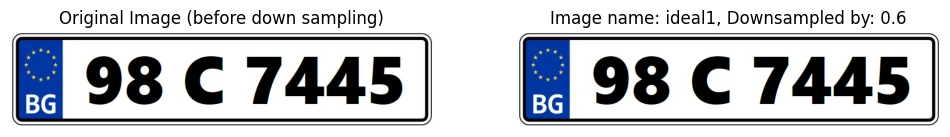

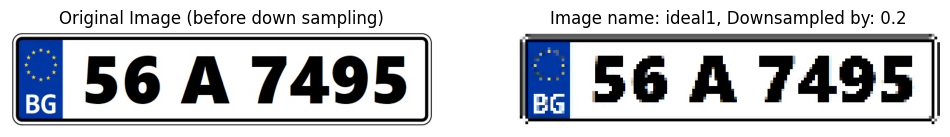

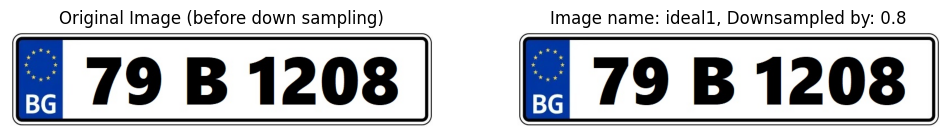

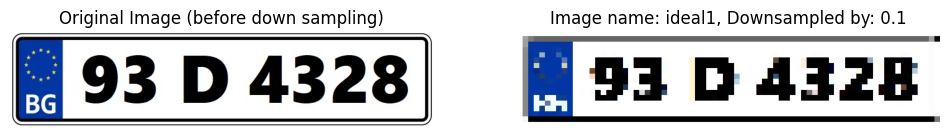

(<PIL.Image.Image image mode=RGB size=758x171>, None)

In [70]:
# PART 1: Function for downsampling:

def down_sampler(input_path, image_name, output_dir, factor, result_show=False, save_result=False):
    img = Image.open(input_path)
    original_size = img.size  # (width height)

    # converting image to numpy array, because we need to select only certain pixels
    img_np = np.array(img)

    # First checking if the down sampling factor is within the valid interval which is (0, 1]
    # Since factor = 0 means we choose no pixels at all (which is obviously not valid)
    # and factor = 1 means we choose all the pixels and there is no down sampling
    if factor <= 0 or factor > 1:
        raise ValueError("Downsampling factor not within the valid region.")

    # Now we determine the step size based on the down sampling factor
    # For example, a factor of 0.33 means that we approximately choose 1 out of each 3 pixels
    # So we just omit some pixels and there is not interpolation
    step = int(1 / factor)

    # Now extracting the subset: taking every 'step'th pixel row-wise and column-wise:
    # (since our image is grayscale):
    img_small = img_np[::step, ::step]
    # (if the image had color, we would have written):
    # img_small = img_np[::step, ::step, :]
    
    # converting the down sampled image back to a PIL image:
    img_small_pil = Image.fromarray(img_small)

    # Now resizing the degraded image back to the original dimensions to compare it with the ideal ones easier
    # Image.NEAREST is the only resizing method that does not interpolate and preserves the blockiness caused by downsampling:
    img_degraded = img_small_pil.resize(original_size, Image.NEAREST)

    if result_show:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.title("Original Image (before down sampling)")
        plt.imshow(img, cmap='gray')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title(f"Image name: {image_name}, Downsampled by: {factor}")
        plt.imshow(img_degraded, cmap='gray')
        plt.axis('off')
        plt.show()

    output_filename = None
    if save_result:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        output_filename = f"{image_name}_dwnsmpl_{factor:.2f}"
        img_degraded.save(str(output_dir) + f"/{output_filename}.png")


    return img_degraded, output_filename



# Some examples to start with
print("Some examples to start with: ")
down_sampler("ideal1.jpg", "ideal1", "", 0.6, result_show=True, save_result=False)
down_sampler("ideal2.jpg", "ideal1", "", 0.2, result_show=True, save_result=False)
down_sampler("ideal3.jpg", "ideal1", "", 0.8, result_show=True, save_result=False)
down_sampler("ideal4.jpg", "ideal1", "", 0.1, result_show=True, save_result=False)

In [71]:
# PART 2: Repeating the character segmentation and recognition processfor multiple downsampling rates (e.g., 1/2, 1/4, 1/6, ...)
# and for each rate, evaluating whether the characters are still recognizable using our correlation-based method:

# Expected_License_Plates = ["98 C 7445", "56 A 7495", "79 B 1208", "93 D 4328"]

# Define all constants needed for batch processing
images_info = [
    {
        "filename": "ideal1.jpg",
        "name": "ideal1",
        "slices": [[132, 205, 25, 150], [205, 280, 25, 150], [310, 390, 25, 150], [420, 490, 25, 150],
                   [488, 567, 25, 150], [563, 642, 25, 150], [640, 710, 25, 150]],
        "expected_lp": Expected_License_Plates[0],
        "index": '1'
    },
    {
        "filename": "ideal2.jpg",
        "name": "ideal2",
        "slices": [[130, 200, 25, 150], [200, 277, 25, 150], [300, 400, 25, 150], [420, 502, 25, 150],
                   [496, 577, 25, 150], [572, 647, 25, 150], [643, 717, 25, 150]],
        "expected_lp": Expected_License_Plates[1],
        "index": '2'
    },
    {
        "filename": "ideal3.jpg",
        "name": "ideal3",
        "slices": [[132, 205, 25, 150], [203, 278, 25, 150], [310, 393, 25, 150], [420, 487, 25, 150],
                   [483, 559, 25, 150], [553, 630, 25, 150], [625, 705, 25, 150]],
        "expected_lp": Expected_License_Plates[2],
        "index": '3'
    },
    {
        "filename": "ideal4.jpg",
        "name": "ideal4",
        "slices": [[125, 200, 25, 150], [197, 274, 25, 150], [300, 400, 25, 150], [420, 505, 25, 150],
                   [499, 577, 25, 150], [572, 647, 25, 150], [643, 719, 25, 150]],
        "expected_lp": Expected_License_Plates[3],
        "index": '4'
    }
]

# Downsampling factors
factors = [1, 0.60, 0.50, 0.25, 0.17]

# Main loop
for img_info in images_info:
    for factor in factors:
        # Step 1: Downsample image
        img, img_flname = down_sampler(
            img_info["filename"],
            img_info["name"],
            "ideal_downsampled",
            factor,
            False,
            True
        )

        # Step 2: Split characters
        character_splitter(
            img,
            img_flname,
            img_info["slices"],
            loading_needed=False,
            output_directory="ideal_downsampled_slices",
            save_slices=True,
            print_slices=False
        )

        # Step 3: Load slice paths
        slice_paths = [
            f"ideal_downsampled_slices/{img_info['name']}_dwnsmpl_{factor:.2f}_slice_{i}.png"
            for i in range(7)
        ]

        # Step 4: Run LPR
        LPR(
            img_info["index"],
            load_slices_from_paths(slice_paths),
            templates,
            downsampled=True,
            factor=factor
        )

        # Step 5: Print expected result
        print("     Expected LP: ", img_info["expected_lp"])


Image Number 1, downsample by: 1
     Recognized license plate: 98 C 7445
     Best correlation scores in order are:  [np.float32(0.9673583), np.float32(0.94752765), np.float32(0.9221602), np.float32(0.92986673), np.float32(0.9689035), np.float32(0.95144296), np.float32(0.95526105)]


     Expected LP:  98 C 7445
Image Number 1, downsample by: 0.6
     Recognized license plate: 98 C 7445
     Best correlation scores in order are:  [np.float32(0.9673583), np.float32(0.94752765), np.float32(0.9221602), np.float32(0.92986673), np.float32(0.9689035), np.float32(0.95144296), np.float32(0.95526105)]


     Expected LP:  98 C 7445
Image Number 1, downsample by: 0.5
     Recognized license plate: 98 C 7445
     Best correlation scores in order are:  [np.float32(0.95469606), np.float32(0.953491), np.float32(0.9374947), np.float32(0.90840095), np.float32(0.95729315), np.float32(0.9799247), np.float32(0.9390802)]


     Expected LP:  98 C 7445
Image Number 1, downsample by: 0.25
     Recognized l

#### **Task 3 (continued):** 
Determining and reporting the minimum sampling rate at which the license plate is still correctly recognizable, and also, plotting or tabulating the findings to show how recognition accuracy changes with sampling rate.

Image Number 1, downsample by: 0.5
     Recognized license plate: 98 C 7445
     Best correlation scores in order are:  [np.float32(0.95469606), np.float32(0.953491), np.float32(0.9374947), np.float32(0.90840095), np.float32(0.95729315), np.float32(0.9799247), np.float32(0.9390802)]


Image Number 1, downsample by: 0.49
     Recognized license plate: 98 C 7445
     Best correlation scores in order are:  [np.float32(0.95469606), np.float32(0.953491), np.float32(0.9374947), np.float32(0.90840095), np.float32(0.95729315), np.float32(0.9799247), np.float32(0.9390802)]


Image Number 1, downsample by: 0.48
     Recognized license plate: 98 C 7445
     Best correlation scores in order are:  [np.float32(0.95469606), np.float32(0.953491), np.float32(0.9374947), np.float32(0.90840095), np.float32(0.95729315), np.float32(0.9799247), np.float32(0.9390802)]


Image Number 1, downsample by: 0.47
     Recognized license plate: 98 C 7445
     Best correlation scores in order are:  [np.float32(0.95469

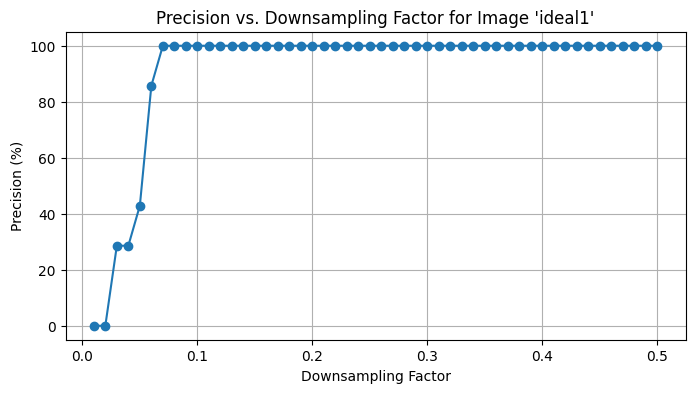

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23756\1817396299.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('nipy_spectral')


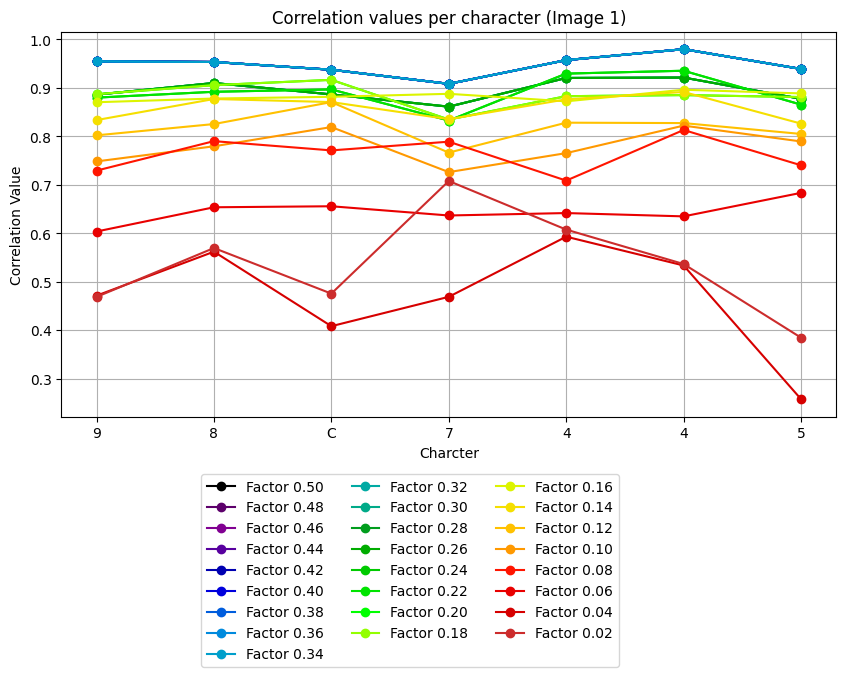

The min sampling rate at which the LP is still correctly recognized: 0.07


In [96]:
#**************************   IMAGE 1   ***************************
factors = [round(x, 2) for x in np.arange(0.5, 0.00, -0.01)]
expected_lp = Expected_License_Plates[0]
correlation_data = []
precision_data = []

slicing_coordinates = [[132, 205, 25, 150], [205, 280, 25, 150], [310, 390, 25, 150],
    [420, 490, 25, 150], [488, 567, 25, 150], [563, 642, 25, 150], [640, 710, 25, 150]]

#########################################################################
for factor in factors:
    img, img_flname = down_sampler("ideal1.jpg", "ideal1", "ideal_plotting_downsampled", factor, False, True)
    character_splitter(
        img, img_flname, slicing_coordinates,
        loading_needed = False, output_directory="ideal_plotting_downsampled_slices",
        save_slices=True, print_slices=False
    )

    slice_paths = [
        f"ideal_plotting_downsampled_slices/ideal1_dwnsmpl_{factor:.2f}_slice_{i}.png"
        for i in range(7)
    ]

    recognized_LP, correlation_vals = LPR('1', load_slices_from_paths(slice_paths), templates, downsampled=True, factor=factor)

    ############## Now calculating the precision:
    number_of_correct_chars = 0
    recognized_LP = recognized_LP.replace(" ", "")
    expected_lp = expected_lp.replace(" ", "")

    for i in range(len(recognized_LP)):
        if(recognized_LP[i] == expected_lp[i]):
            number_of_correct_chars += 1
    precision = (number_of_correct_chars / len(expected_lp)) * 100

    ############## Appending the results of this run to the lists we want to plot later
    precision_data.append(precision)
    correlation_data.append(correlation_vals)
    

#########################################################################

# Now plotting Precision vs. Downsampling factor
plt.figure(figsize=(8, 4))
plt.plot(factors, precision_data, marker='o')
plt.title("Precision vs. Downsampling Factor for Image 'ideal1'")
plt.xlabel("Downsampling Factor")
plt.ylabel("Precision (%)")
plt.grid(True)
plt.show()

#########################################################################

# Now plotting correlation values for each factor
plt.figure(figsize=(10, 5))
x_labels = ['9','8','C','7','4','4','5']
x_positions = list(range(len(x_labels)))
color_map = cm.get_cmap('nipy_spectral')
colors = [color_map(i / len(range(0, len(correlation_data), 2))) for i in range(len(range(0, len(correlation_data), 2)))]

for idx in range(0, len(correlation_data), 2):
    plt.plot(
        x_positions,
        correlation_data[idx],
        marker='o',
        label=f"Factor {factors[idx]:.2f}",
        color=colors[idx//2]
    )

plt.xticks(ticks=x_positions, labels=x_labels)

plt.title("Correlation values per character (Image 1)")
plt.xlabel("Charcter")
plt.ylabel("Correlation Value")
plt.legend(ncol=3, loc='center', bbox_to_anchor=(0.45, -0.4))
plt.grid()
plt.show()

#########################################################################

# Figuring out the min sampling rate acceptable

# print(f"precision_data: {precision_data}")
precision_data = precision_data[::-1]  # reversing the order so that the precisions of 100 are moved to the end of the list 
factors = factors[::-1]
# for i in range(len(precision_data)):
#     print(f"{factors[i]} : precision = {precision_data[i]}")

min_valid_factor = None

for i in range(len(precision_data)):
    # From this index to the end, check if all precisions are 100
    # since the valid region is where we have no fluctuation in the precision of 100
    if all(p == 100 for p in precision_data[i:]):
        min_valid_factor = factors[i]  # first such index gives the smallest valid factor
        break  # stop early — this is the min one we want

if min_valid_factor is not None:
    print(f"The min sampling rate at which the LP is still correctly recognized: {min_valid_factor}")
else:
    print("No range found where precision stays at 100% continuously.")


Image Number 2, downsample by: 0.5
     Recognized license plate: 56 A 7495
     Best correlation scores in order are:  [np.float32(0.9599486), np.float32(0.97380173), np.float32(0.9729805), np.float32(0.8175996), np.float32(0.944608), np.float32(0.97084105), np.float32(0.9005638)]


Image Number 2, downsample by: 0.49
     Recognized license plate: 56 A 7495
     Best correlation scores in order are:  [np.float32(0.9599486), np.float32(0.97380173), np.float32(0.9729805), np.float32(0.8175996), np.float32(0.944608), np.float32(0.97084105), np.float32(0.9005638)]


Image Number 2, downsample by: 0.48
     Recognized license plate: 56 A 7495
     Best correlation scores in order are:  [np.float32(0.9599486), np.float32(0.97380173), np.float32(0.9729805), np.float32(0.8175996), np.float32(0.944608), np.float32(0.97084105), np.float32(0.9005638)]


Image Number 2, downsample by: 0.47
     Recognized license plate: 56 A 7495
     Best correlation scores in order are:  [np.float32(0.9599486)

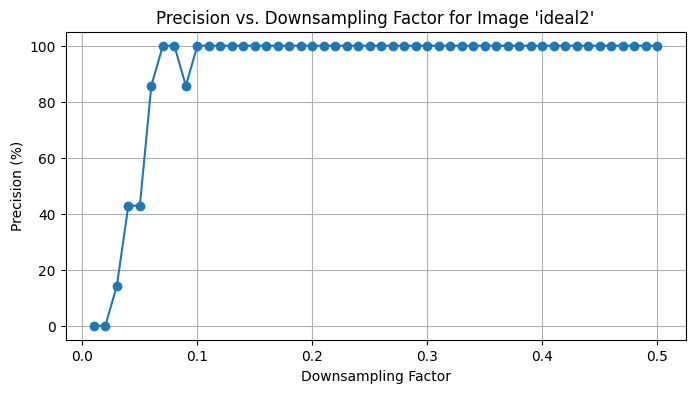

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23756\153856785.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('nipy_spectral')


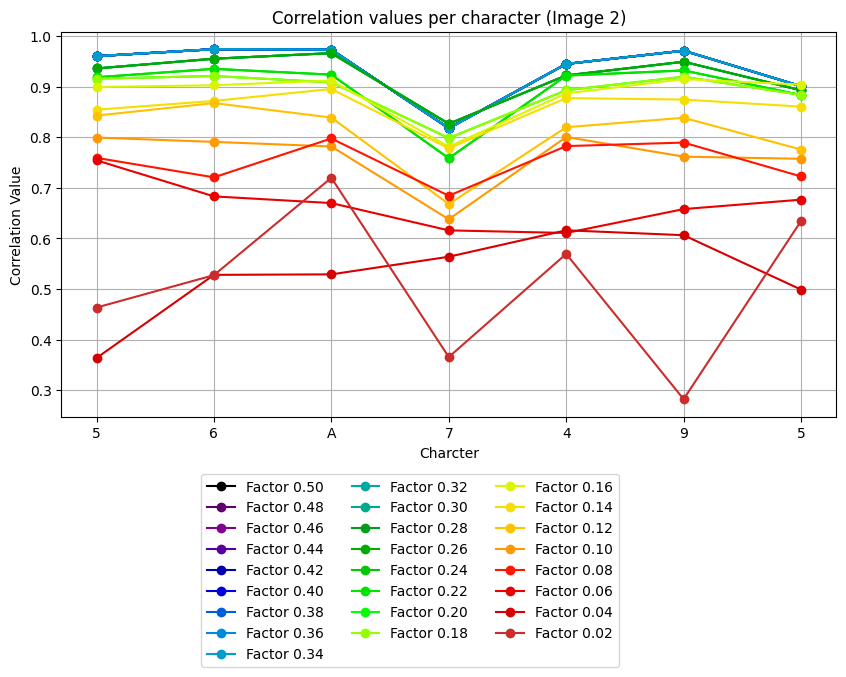

The min sampling rate at which the LP is still correctly recognized: 0.1


In [95]:
#**************************   IMAGE 2   ***************************
factors = [round(x, 2) for x in np.arange(0.5, 0.00, -0.01)]
expected_lp = Expected_License_Plates[1]
correlation_data = []
precision_data = []

slicing_coordinates = [[130, 200, 25, 150], [200, 277, 25, 150],
                       [300, 400, 25, 150], [420, 502, 25, 150], [496, 577, 25, 150], [572, 647, 25, 150], [643, 717, 25, 150]]

#########################################################################

for factor in factors:
    img, img_flname = down_sampler("ideal2.jpg", "ideal2", "ideal_plotting_downsampled", factor, False, True)
    character_splitter(
        img, img_flname, slicing_coordinates,
        loading_needed = False, output_directory="ideal_plotting_downsampled_slices",
        save_slices=True, print_slices=False
    )

    slice_paths = [
        f"ideal_plotting_downsampled_slices/ideal2_dwnsmpl_{factor:.2f}_slice_{i}.png"
        for i in range(7)
    ]

    recognized_LP, correlation_vals = LPR('2', load_slices_from_paths(slice_paths), templates, downsampled=True, factor=factor)

    ############## Now calculating the precision:
    number_of_correct_chars = 0
    recognized_LP = recognized_LP.replace(" ", "")
    expected_lp = expected_lp.replace(" ", "")

    for i in range(len(recognized_LP)):
        if(recognized_LP[i] == expected_lp[i]):
            number_of_correct_chars += 1
    precision = (number_of_correct_chars / len(expected_lp)) * 100

    ############## Appending the results of this run to the lists we want to plot later
    precision_data.append(precision)
    correlation_data.append(correlation_vals)
    


#########################################################################

# Now plotting Precision vs. Downsampling factor
plt.figure(figsize=(8, 4))
plt.plot(factors, precision_data, marker='o')
plt.title("Precision vs. Downsampling Factor for Image 'ideal2'")
plt.xlabel("Downsampling Factor")
plt.ylabel("Precision (%)")
plt.grid(True)
plt.show()

#########################################################################

# Now plotting correlation values for each factor
plt.figure(figsize=(10, 5))
x_labels = ['5', '6', 'A', '7', '4', '9', '5']
x_positions = list(range(len(x_labels)))
color_map = cm.get_cmap('nipy_spectral')
colors = [color_map(i / len(range(0, len(correlation_data), 2))) for i in range(len(range(0, len(correlation_data), 2)))]

for idx in range(0, len(correlation_data), 2):
    plt.plot(
        x_positions,
        correlation_data[idx],
        marker='o',
        label=f"Factor {factors[idx]:.2f}",
        color=colors[idx//2]
    )

plt.xticks(ticks=x_positions, labels=x_labels)

plt.title("Correlation values per character (Image 2)")
plt.xlabel("Charcter")
plt.ylabel("Correlation Value")
plt.legend(ncol=3, loc='center', bbox_to_anchor=(0.45, -0.4))
plt.grid()
plt.show()

#########################################################################

# Figuring out the min sampling rate acceptable
# print(f"precision_data: {precision_data}")
precision_data = precision_data[::-1]  # reversing the order so that the precisions of 100 are moved to the end of the list 
factors = factors[::-1]
# for i in range(len(precision_data)):
#     print(f"{factors[i]} : precision = {precision_data[i]}")

min_valid_factor = None

for i in range(len(precision_data)):
    # From this index to the end, check if all precisions are 100
    # since the valid region is where we have no fluctuation in the precision of 100
    if all(p == 100 for p in precision_data[i:]):
        min_valid_factor = factors[i]  # first such index gives the smallest valid factor
        break  # stop early — this is the min one we want

if min_valid_factor is not None:
    print(f"The min sampling rate at which the LP is still correctly recognized: {min_valid_factor}")
else:
    print("No range found where precision stays at 100% continuously.")

Image Number 3, downsample by: 0.9
     Recognized license plate: 79 B 1208
     Best correlation scores in order are:  [np.float32(0.88616055), np.float32(0.9105918), np.float32(0.86529326), np.float32(0.91316366), np.float32(0.8831287), np.float32(0.9494847), np.float32(0.8807714)]


Image Number 3, downsample by: 0.88
     Recognized license plate: 79 B 1208
     Best correlation scores in order are:  [np.float32(0.88616055), np.float32(0.9105918), np.float32(0.86529326), np.float32(0.91316366), np.float32(0.8831287), np.float32(0.9494847), np.float32(0.8807714)]


Image Number 3, downsample by: 0.86
     Recognized license plate: 79 B 1208
     Best correlation scores in order are:  [np.float32(0.88616055), np.float32(0.9105918), np.float32(0.86529326), np.float32(0.91316366), np.float32(0.8831287), np.float32(0.9494847), np.float32(0.8807714)]


Image Number 3, downsample by: 0.84
     Recognized license plate: 79 B 1208
     Best correlation scores in order are:  [np.float32(0.88

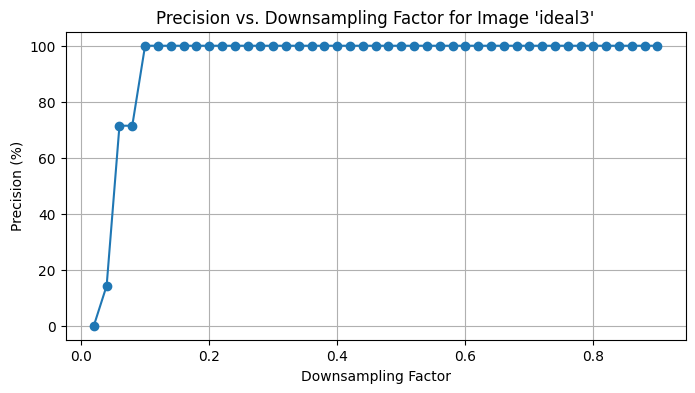

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23756\3328630021.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('nipy_spectral')


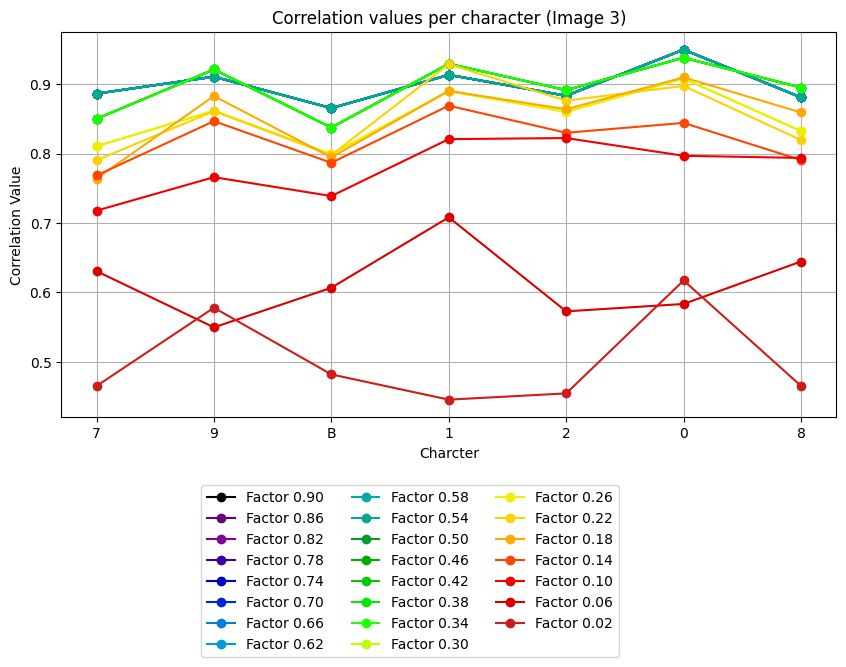

The min sampling rate at which the LP is still correctly recognized: 0.1


In [94]:
#**************************   IMAGE 3   ***************************
factors = [round(x, 2) for x in np.arange(0.9, 0.00, -0.02)]
expected_lp = Expected_License_Plates[2]
correlation_data = []
precision_data = []

slicing_coordinates = [[132, 205, 25, 150], [203, 278, 25, 150], 
                       [310, 393, 25, 150], [420, 487, 25, 150], [483, 559, 25, 150], [553, 630, 25, 150], [625, 705, 25, 150]]
#########################################################################

for factor in factors:
    img, img_flname = down_sampler("ideal3.jpg", "ideal3", "ideal_plotting_downsampled", factor, False, True)
    character_splitter(
        img, img_flname, slicing_coordinates,
        loading_needed = False, output_directory="ideal_plotting_downsampled_slices",
        save_slices=True, print_slices=False
    )

    slice_paths = [
        f"ideal_plotting_downsampled_slices/ideal3_dwnsmpl_{factor:.2f}_slice_{i}.png"
        for i in range(7)
    ]

    recognized_LP, correlation_vals = LPR('3', load_slices_from_paths(slice_paths), templates, downsampled=True, factor=factor)

    ############## Now calculating the precision:
    number_of_correct_chars = 0
    recognized_LP = recognized_LP.replace(" ", "")
    expected_lp = expected_lp.replace(" ", "")

    for i in range(len(recognized_LP)):
        if(recognized_LP[i] == expected_lp[i]):
            number_of_correct_chars += 1
    precision = (number_of_correct_chars / len(expected_lp)) * 100

    ############## Appending the results of this run to the lists we want to plot later
    precision_data.append(precision)
    correlation_data.append(correlation_vals)
    


#########################################################################

# Now plotting Precision vs. Downsampling factor
plt.figure(figsize=(8, 4))
plt.plot(factors, precision_data, marker='o')
plt.title("Precision vs. Downsampling Factor for Image 'ideal3'")
plt.xlabel("Downsampling Factor")
plt.ylabel("Precision (%)")
plt.grid(True)
plt.show()

#########################################################################

# Now plotting correlation values for each factor
plt.figure(figsize=(10, 5))
x_labels = ['7','9','B','1','2','0','8']
x_positions = list(range(len(x_labels)))
color_map = cm.get_cmap('nipy_spectral')
colors = [color_map(i / len(range(0, len(correlation_data), 2))) for i in range(len(range(0, len(correlation_data), 2)))]

for idx in range(0, len(correlation_data), 2):
    plt.plot(
        x_positions,
        correlation_data[idx],
        marker='o',
        label=f"Factor {factors[idx]:.2f}",
        color=colors[idx//2]
    )

plt.xticks(ticks=x_positions, labels=x_labels)

plt.title("Correlation values per character (Image 3)")
plt.xlabel("Charcter")
plt.ylabel("Correlation Value")
plt.legend(ncol=3, loc='center', bbox_to_anchor=(0.45, -0.4))
plt.grid()
plt.show()

#########################################################################

# Figuring out the min sampling rate acceptable

# print(f"precision_data: {precision_data}")
precision_data = precision_data[::-1]  # reversing the order so that the precisions of 100 are moved to the end of the list 
factors = factors[::-1]
# for i in range(len(precision_data)):
#     print(f"{factors[i]} : precision = {precision_data[i]}")

min_valid_factor = None

for i in range(len(precision_data)):
    # From this index to the end, check if all precisions are 100
    # since the valid region is where we have no fluctuation in the precision of 100
    if all(p == 100 for p in precision_data[i:]):
        min_valid_factor = factors[i]  # first such index gives the smallest valid factor
        break  # stop early — this is the min one we want

if min_valid_factor is not None:
    print(f"The min sampling rate at which the LP is still correctly recognized: {min_valid_factor}")
else:
    print("No range found where precision stays at 100% continuously.")


Image Number 4, downsample by: 0.5
     Recognized license plate: 93 D 4328
     Best correlation scores in order are:  [np.float32(0.9500054), np.float32(0.9211018), np.float32(0.92707586), np.float32(0.86689466), np.float32(0.919819), np.float32(0.87515223), np.float32(0.951275)]


Image Number 4, downsample by: 0.49
     Recognized license plate: 93 D 4328
     Best correlation scores in order are:  [np.float32(0.9500054), np.float32(0.9211018), np.float32(0.92707586), np.float32(0.86689466), np.float32(0.919819), np.float32(0.87515223), np.float32(0.951275)]


Image Number 4, downsample by: 0.48
     Recognized license plate: 93 D 4328
     Best correlation scores in order are:  [np.float32(0.9500054), np.float32(0.9211018), np.float32(0.92707586), np.float32(0.86689466), np.float32(0.919819), np.float32(0.87515223), np.float32(0.951275)]


Image Number 4, downsample by: 0.47
     Recognized license plate: 93 D 4328
     Best correlation scores in order are:  [np.float32(0.9500054)

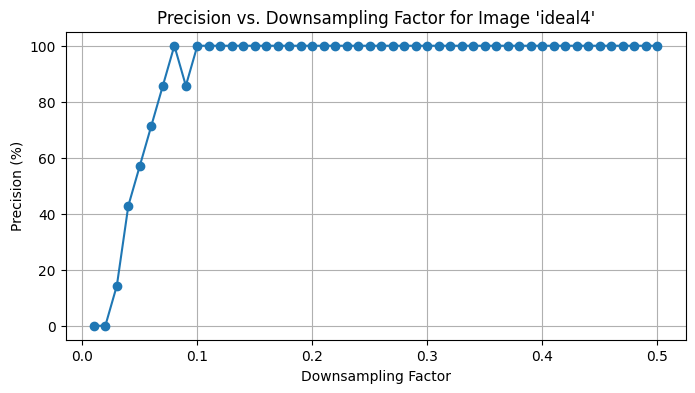

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23756\2802112013.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('nipy_spectral')


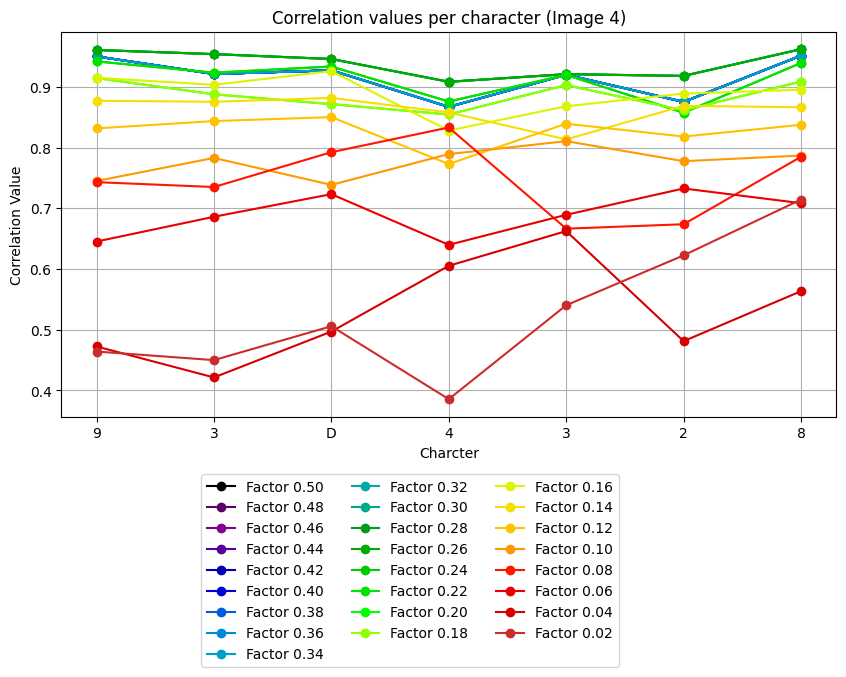

The min sampling rate at which the LP is still correctly recognized: 0.1


In [ ]:
#**************************   IMAGE 4   ***************************
factors = [round(x, 2) for x in np.arange(0.5, 0.00, -0.01)]
expected_lp = Expected_License_Plates[3]
correlation_data = []
precision_data = []

slicing_coordinates = [[125, 200, 25, 150], [197, 274, 25, 150], [300, 400, 25, 150], 
                       [420, 505, 25, 150], [499, 577, 25, 150], [572, 647, 25, 150], [643, 719, 25, 150]]

#########################################################################

for factor in factors:
    img, img_flname = down_sampler("ideal4.jpg", "ideal4", "ideal_plotting_downsampled", factor, False, True)
    character_splitter(
        img, img_flname, slicing_coordinates,
        loading_needed = False, output_directory="ideal_plotting_downsampled_slices",
        save_slices=True, print_slices=False
    )

    slice_paths = [
        f"ideal_plotting_downsampled_slices/ideal4_dwnsmpl_{factor:.2f}_slice_{i}.png"
        for i in range(7)
    ]

    recognized_LP, correlation_vals = LPR('4', load_slices_from_paths(slice_paths), templates, downsampled=True, factor=factor)

    ############## Now calculating the precision:
    number_of_correct_chars = 0
    recognized_LP = recognized_LP.replace(" ", "")
    expected_lp = expected_lp.replace(" ", "")

    for i in range(len(recognized_LP)):
        if(recognized_LP[i] == expected_lp[i]):
            number_of_correct_chars += 1
    precision = (number_of_correct_chars / len(expected_lp)) * 100


    # print('len(correlation_vals)', len(correlation_vals))
    ############## Appending the results of this run to the lists we want to plot later
    precision_data.append(precision)
    correlation_data.append(correlation_vals)


#########################################################################

# Now plotting Precision vs. Downsampling factor
plt.figure(figsize=(8, 4))
plt.plot(factors, precision_data, marker='o')
plt.title("Precision vs. Downsampling Factor for Image 'ideal4'")
plt.xlabel("Downsampling Factor")
plt.ylabel("Precision (%)")
plt.grid(True)
plt.show()

#########################################################################

# Now plotting correlation values per characterf for each factor
plt.figure(figsize=(10, 5))
x_labels = ['9','3','D','4','3','2','8']
x_positions = list(range(len(x_labels)))
color_map = cm.get_cmap('nipy_spectral')
colors = [color_map(i / len(range(0, len(correlation_data), 2))) for i in range(len(range(0, len(correlation_data), 2)))]

for idx in range(0, len(correlation_data), 2):
    plt.plot(
        x_positions,
        correlation_data[idx],
        marker='o',
        label=f"Factor {factors[idx]:.2f}",
        color=colors[idx//2]
    )

plt.xticks(ticks=x_positions, labels=x_labels)

plt.title("Correlation values per character (Image 4)")
plt.xlabel("Charcter")
plt.ylabel("Correlation Value")
#  plt.xticks(range(1, 8))
plt.legend(ncol=3, loc='center', bbox_to_anchor=(0.45, -0.4))
plt.grid()
plt.show()

#########################################################################

# Figuring out the min sampling rate acceptable

# print(f"precision_data: {precision_data}")
precision_data = precision_data[::-1]  # reversing the order so that the precisions of 100 are moved to the end of the list 
factors = factors[::-1]
# for i in range(len(precision_data)):
#     print(f"{factors[i]} : precision = {precision_data[i]}")

min_valid_factor = None

for i in range(len(precision_data)):
    # From this index to the end, check if all precisions are 100
    # since the valid region is where we have no fluctuation in the precision of 100
    if all(p == 100 for p in precision_data[i:]):
        min_valid_factor = factors[i]  # first such index gives the smallest valid factor
        break  # stop early — this is the min one we want

if min_valid_factor is not None:
    print(f"The min sampling rate at which the LP is still correctly recognized: {min_valid_factor}")
else:
    print("No range found where precision stays at 100% continuously.")

In the plots above, the reason why some traces in the correlation values per character are not shown is that the correlation values for larger down sampling rates (approx. 0.5 to 0.35) are so close together that they are regarded as the same values, resulting in fully overlapping traces.